🔍 Dataset size: 176
🔍 Ground truth distribution:
 ground_truth
A    90
B    86
Name: count, dtype: int64
🔍 Prediction distribution:
 predicted_label
A          103
B           64
unknown      9
Name: count, dtype: int64
❓ Unknown predictions: 5.11%


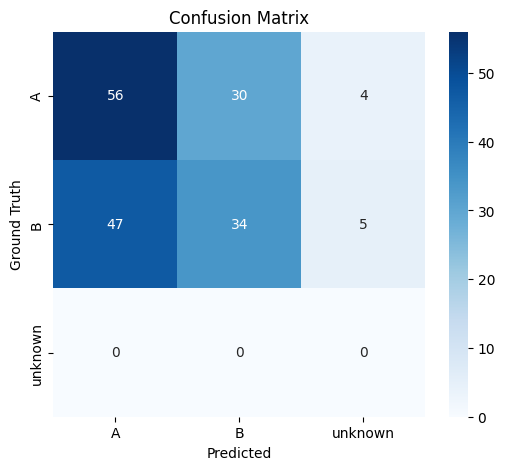


📊 Classification Report:
              precision    recall  f1-score   support

           A       0.54      0.62      0.58        90
           B       0.53      0.40      0.45        86

   micro avg       0.54      0.51      0.52       176
   macro avg       0.54      0.51      0.52       176
weighted avg       0.54      0.51      0.52       176


📏 Output Length by Prediction:
                 count         mean         std     min      25%     50%  \
predicted_label                                                            
A                103.0  4334.776699  878.087203  2679.0  3703.00  4203.0   
B                 64.0  4385.984375  733.942117  2383.0  3888.25  4432.5   
unknown            9.0  4694.777778  405.121827  4241.0  4578.00  4684.0   

                    75%     max  
predicted_label                  
A                4860.5  7069.0  
B                4827.5  6378.0  
unknown          4751.0  5634.0  


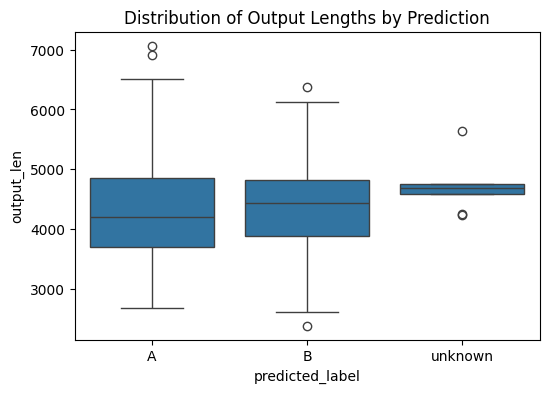


❌ Total Errors: 86

🔎 Sample Errors:
GT: B | Pred: A
Output (truncated):
 <rubric>
1. Execution Success: Based on the proposal content, how likely is it to execute successfully in the ASD Agent? (1.0 = yes (completed status), 0.0 = no (with error or failed status))
2. Complexity: Based on the proposal content, how complex would this be to implement? (1.0 = very complex (in terms of utlizing complete Reflection Budget), 0.0 = very simple (utilizing less reflection budget))
3. Cost Efficiency: Based on the proposal content, how cost-efficient would this be to execute? (1.0 = very cost-efficient, 0.0 = very costly)
4. Expected Hypothesis Validity: Based on the proposal content, how likely is the hypothesis to yield valid/conclusive results? (1.0 = very valid (support/reject), 0.0 = not valid (inconclusive))
5. Expected Interestingness: Based on the proposal content ...

GT: B | Pred: A
Output (truncated):
 <rubric>
1. Execution Success: Based on the proposal content, how likely is it to 

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ------------------ Load ------------------ #
#df = pd.read_csv("../validation_predictions.csv")
#df = pd.read_csv("test_harpa_rlvr_sep21_predictions_failure_success.csv")
df = pd.read_csv("validation_baseline_sep21_predictions_all_data_with_gt_reas.csv")


# ------------------ Basic Stats ------------------ #
print("🔍 Dataset size:", len(df))
print("🔍 Ground truth distribution:\n", df["ground_truth"].value_counts())
print("🔍 Prediction distribution:\n", df["predicted_label"].value_counts())

# ------------------ Unknown Rate ------------------ #
unknown_rate = (df["predicted_label"] == "unknown").mean()
print(f"❓ Unknown predictions: {unknown_rate:.2%}")

# ------------------ Confusion Matrix ------------------ #
labels = ["A", "B", "unknown"]
cm = confusion_matrix(df["ground_truth"], df["predicted_label"], labels=labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Ground Truth")
plt.title("Confusion Matrix")
plt.show()

# ------------------ Classification Report ------------------ #
print("\n📊 Classification Report:")
print(classification_report(df["ground_truth"], df["predicted_label"], labels=["A", "B"]))

# ------------------ Output Length Analysis ------------------ #
df["output_len"] = df["model_output"].str.len()
print("\n📏 Output Length by Prediction:")
print(df.groupby("predicted_label")["output_len"].describe())

plt.figure(figsize=(6,4))
sns.boxplot(x="predicted_label", y="output_len", data=df)
plt.title("Distribution of Output Lengths by Prediction")
plt.show()

# ------------------ Error Analysis ------------------ #
errors = df[df["ground_truth"] != df["predicted_label"]]
print(f"\n❌ Total Errors: {len(errors)}")

if len(errors) > 0:
    print("\n🔎 Sample Errors:")
    sample_errors = errors.sample(min(5, len(errors)), random_state=42)
    for _, row in sample_errors.iterrows():
        print("="*80)
        print(f"GT: {row['ground_truth']} | Pred: {row['predicted_label']}")
        print("Output (truncated):\n", row["model_output"][:800], "...\n")

# ------------------ Bias Check ------------------ #
print("\n⚖️ Prediction Distribution per Ground Truth:")
print(df.groupby("ground_truth")["predicted_label"].value_counts(normalize=True).unstack(fill_value=0))


In [ ]:
import pandas as pd
import evaluate

# Load CSV
df = pd.read_csv("/weka/harpa-cs/harpa-rlvr-branch/hypothesis_generation/ASD-specific/RM-R1-data/validation_harpa_rlvr_sep21_predictions_all_data_with_gt_reas.csv")


# Take columns
references = df["ground_truth_reason"].astype(str).tolist()
predictions = df["model_output"].astype(str).tolist()

# Load metrics
bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")

# Compute BLEU
bleu_score = bleu.compute(predictions=predictions, references=references)

# Compute ROUGE
rouge_score = rouge.compute(predictions=predictions, references=references)

print("BLEU:", bleu_score)
print("ROUGE:", rouge_score)


BLEU: {'bleu': 0.31676640377489984, 'precisions': [0.600908719721212, 0.34953906101501614, 0.2483377248470897, 0.1930232115315041], 'brevity_penalty': 1.0, 'length_ratio': 1.1141874735505712, 'translation_length': 210626, 'reference_length': 189040}
ROUGE: {'rouge1': 0.582820372697733, 'rouge2': 0.2770004518445178, 'rougeL': 0.3033081723242451, 'rougeLsum': 0.5541966454572358}


In [1]:
import re
import pandas as pd
import evaluate

df = pd.read_csv("/weka/harpa-cs/harpa-rlvr-branch/hypothesis_generation/ASD-specific/RM-R1-data/validation_baseline_sep21_predictions_all_data_with_gt_reas.csv")
# Define rubric headings to strip
rubric_dims = [
    "Execution Success",
    "Complexity",
    "Cost Efficiency",
    "Expected Hypothesis Validity",
    "Expected Interestingness",
    "Faithfulness"
]

def clean_text(text):
    """Remove rubric headings, numbering, and tags."""
    if not isinstance(text, str):
        return ""
    
    # Remove rubric headings
    for dim in rubric_dims:
        text = re.sub(dim, "", text, flags=re.IGNORECASE)
    
    # Remove XML-like tags e.g., <rubric>, </eval>, <summary_A>...</summary_A>
    text = re.sub(r"<[^>]+>", " ", text)
    
    # Remove numbered list prefixes like "1.", "2-" etc.
    text = re.sub(r"\d+[\.\-:]", " ", text)
    
    # Collapse whitespace
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Apply cleaning
df["gt_reason_clean"] = df["ground_truth_reason"].apply(clean_text)
df["model_reason_clean"] = df["model_output"].apply(clean_text)

# Prepare data
references = df["gt_reason_clean"].tolist()
predictions = df["model_reason_clean"].tolist()

# Load metrics
bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")

# Compute raw scores
bleu_raw = bleu.compute(predictions=df["model_output"].astype(str).tolist(),
                        references=df["ground_truth_reason"].astype(str).tolist())
rouge_raw = rouge.compute(predictions=df["model_output"].astype(str).tolist(),
                          references=df["ground_truth_reason"].astype(str).tolist())

# Compute cleaned scores
bleu_clean = bleu.compute(predictions=predictions, references=references)
rouge_clean = rouge.compute(predictions=predictions, references=references)

print("Raw BLEU/ROUGE (with rubric + tags):")
print("BLEU:", bleu_raw)
print("ROUGE:", rouge_raw)

print("\nContent-only BLEU/ROUGE (rubric headings + tags stripped):")
print("BLEU:", bleu_clean)
print("ROUGE:", rouge_clean)


/opt/miniconda3/envs/rm-r1/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Raw BLEU/ROUGE (with rubric + tags):
BLEU: {'bleu': 0.1700384025906228, 'precisions': [0.5451463770548962, 0.24397496896979726, 0.1486129629389911, 0.10221234350294202], 'brevity_penalty': 0.8020333109889969, 'length_ratio': 0.8192657638595007, 'translation_length': 154874, 'reference_length': 189040}
ROUGE: {'rouge1': 0.4666742097345145, 'rouge2': 0.16273292830898223, 'rougeL': 0.20200961544575852, 'rougeLsum': 0.44173495246272737}

Content-only BLEU/ROUGE (rubric headings + tags stripped):
BLEU: {'bleu': 0.08126487495320411, 'precisions': [0.48441613182862914, 0.14455249974114517, 0.05669753603420358, 0.02794353775732739], 'brevity_penalty': 0.791827219745135, 'length_ratio': 0.8107590529247911, 'translation_length': 125739, 'reference_length': 155088}
ROUGE: {'rouge1': 0.4289384004149891, 'rouge2': 0.12640950746575103, 'rougeL': 0.1745585634585328, 'rougeLsum': 0.17444999998235172}


In [4]:
import re
import pandas as pd
import evaluate
import sacrebleu
from scipy.stats import ttest_rel, wilcoxon

# ========== CONFIG ==========
# ========== CONFIG ==========
file_baseline = "/weka/harpa-cs/harpa-rlvr-branch/hypothesis_generation/ASD-specific/RM-R1-data/validation_baseline_sep21_predictions_all_data_with_gt_reas.csv"
file_system   = "/weka/harpa-cs/harpa-rlvr-branch/hypothesis_generation/ASD-specific/RM-R1-data/validation_harpa_rlvr_sep21_predictions_all_data_with_gt_reas.csv"

rubric_dims = [
    "Execution Success",
    "Complexity",
    "Cost Efficiency",
    "Expected Hypothesis Validity",
    "Expected Interestingness",
    "Faithfulness"
]

# ========== CLEANING ==========
def clean_text(text):
    if not isinstance(text, str):
        return ""
    for dim in rubric_dims:
        text = re.sub(dim, "", text, flags=re.IGNORECASE)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\d+[\.\-:]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# ========== LOAD DATA ==========
df_base = pd.read_csv(file_baseline)
df_sys  = pd.read_csv(file_system)

assert len(df_base) == len(df_sys), "Mismatch in dataset sizes!"

references = df_base["ground_truth_reason"].apply(clean_text).tolist()
preds_base = df_base["model_output"].apply(clean_text).tolist()
preds_sys  = df_sys["model_output"].apply(clean_text).tolist()

# ========== METRICS ==========
rouge = evaluate.load("rouge")
bleu = evaluate.load("bleu")

# Per-example ROUGE
rouge_base = rouge.compute(predictions=preds_base, references=references, use_aggregator=False)
rouge_sys  = rouge.compute(predictions=preds_sys,  references=references, use_aggregator=False)

# Per-example BLEU (sentence-level)
bleu_scores_base = [sacrebleu.sentence_bleu(p, [r]).score for p, r in zip(preds_base, references)]
bleu_scores_sys  = [sacrebleu.sentence_bleu(p, [r]).score for p, r in zip(preds_sys,  references)]

# ========== STATISTICAL TESTS ==========
def significance_marker(p):
    if p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "n.s."

def run_tests(metric, base_scores, sys_scores):
    t_stat, t_p = ttest_rel(sys_scores, base_scores)
    w_stat, w_p = wilcoxon(sys_scores, base_scores)
    mean_base = sum(base_scores) / len(base_scores)
    mean_sys  = sum(sys_scores)  / len(sys_scores)
    
    mark_t = significance_marker(t_p)
    mark_w = significance_marker(w_p)

    print(f"\n{metric}:")
    print(f"  Baseline: {mean_base:.4f} | System: {mean_sys:.4f}")
    print(f"  Paired t-test: t={t_stat:.3f}, p={t_p:.4g} ({mark_t})")
    print(f"  Wilcoxon: W={w_stat:.3f}, p={w_p:.4g} ({mark_w})")

    # LaTeX-friendly line
    print(f"  LaTeX: {metric} & {mean_base:.3f} & {mean_sys:.3f}{mark_w} \\\\")

# Run for BLEU
run_tests("Sentence BLEU", bleu_scores_base, bleu_scores_sys)

# Run for each ROUGE variant
for metric in ["rouge1", "rouge2", "rougeL", "rougeLsum"]:
    run_tests(metric.upper(), rouge_base[metric], rouge_sys[metric])



Sentence BLEU:
  Baseline: 7.5873 | System: 21.0501
  Paired t-test: t=32.454, p=2.69e-78 (**)
  Wilcoxon: W=14.000, p=3.558e-32 (**)
  LaTeX: Sentence BLEU & 7.587 & 21.050** \\

ROUGE1:
  Baseline: 0.4290 | System: 0.5446
  Paired t-test: t=26.927, p=6.529e-66 (**)
  Wilcoxon: W=54.000, p=6.784e-32 (**)
  LaTeX: ROUGE1 & 0.429 & 0.545** \\

ROUGE2:
  Baseline: 0.1264 | System: 0.2231
  Paired t-test: t=24.511, p=5.27e-60 (**)
  Wilcoxon: W=94.000, p=1.29e-31 (**)
  LaTeX: ROUGE2 & 0.126 & 0.223** \\

ROUGEL:
  Baseline: 0.1745 | System: 0.2602
  Paired t-test: t=23.263, p=7.918e-57 (**)
  Wilcoxon: W=96.000, p=1.332e-31 (**)
  LaTeX: ROUGEL & 0.175 & 0.260** \\

ROUGELSUM:
  Baseline: 0.1745 | System: 0.2602
  Paired t-test: t=23.263, p=7.918e-57 (**)
  Wilcoxon: W=96.000, p=1.332e-31 (**)
  LaTeX: ROUGELSUM & 0.175 & 0.260** \\


In [ ]:
## To Do
##BLEURT https://github.com/google-research/bleurt

In [ ]:
!pip install evaluate

In [ ]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
import os

# ------------------ Hugging Face Token ------------------ #
hf_token = os.getenv("HUGGINGFACE_TOKEN")

# ------------------ Config ------------------ #
#model_id = "ROOT/harpa_reasoning_distilled_final"
# model_id = "Qwen/Qwen2.5-7B-Instruct"
model_id = "/weka/harpa-cs/harpa-rlvr-branch/hypothesis_generation/ASD-specific/harpa_rlvr/RM-R1-Qwen2.5-Instruct-7B-RLVR-after-Distill-LR1.0e-6/global_step_648/actor/huggingface"


dataset_id = "ROOT/harpa-rmr1-sft-split-dataset"
split = "validation"   # choose from ["train", "validation", "test"]
sample_idx = 2        # pick which example to inspect

max_new_tokens = 8912

# ------------------ Load ------------------ #
print("Loading model + tokenizer...")
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype="auto",
    device_map="auto",
    attn_implementation="flash_attention_2",
    trust_remote_code=True,
    use_auth_token=hf_token if hf_token else None,
)
tokenizer = AutoTokenizer.from_pretrained(
    model_id,
    trust_remote_code=True,
    use_auth_token=hf_token if hf_token else None,
)
model.eval()

# ------------------ Helpers ------------------ #
def extract_winner_from_trace(text: str):
    if "<answer>[[A]]</answer>" in text:
        return "A"
    elif "<answer>[[B]]</answer>" in text:
        return "B"
    return "unknown"

def generate_output(messages):
    input_ids = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            input_ids=input_ids,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    return tokenizer.decode(
        outputs[0][len(input_ids[0]):],
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True,
    )

# ------------------ Load Dataset ------------------ #
dataset = load_dataset(dataset_id, split=split)
sample = dataset[sample_idx]

# ------------------ Print Oracle ------------------ #
print("\n=== ORACLE (teacher trace from dataset) ===")
print(sample["winner"])  # truncate long text
print("\nGround truth label:", sample["ground_truth"])

# ------------------ Run Student Model ------------------ #
output = generate_output(sample["context_messages"])

print("\n=== STUDENT MODEL OUTPUT ===")
print(output)  # truncate long text

# ------------------ Compare ------------------ #
oracle_answer = extract_winner_from_trace(sample["winner"])
student_answer = extract_winner_from_trace(output)

print("\nOracle Answer:", oracle_answer)
print("Student Answer:", student_answer)
print("Match?", oracle_answer == student_answer)


Loading model + tokenizer...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loading checkpoint shards: 100%|██████████| 4/4 [00:05<00:00,  1.35s/it]
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



=== ORACLE (teacher trace from dataset) ===
<rubric>
1. Execution Success: 
   - Proposal A: 0.9 - Well-structured with clear implementation steps, uses established datasets (Spider), and has reasonable scope with pilot modes
   - Proposal B: 0.3 - Overly complex with transformer training, attention mechanism modifications, and multiple datasets requiring significant computational resources

2. Complexity:
   - Proposal A: 0.3 - Moderate complexity involving LLM prompting, constrained decoding, and evaluation metrics
   - Proposal B: 0.8 - Very high complexity requiring transformer model training, attention mechanism modifications, and multi-dataset evaluation

3. Cost Efficiency:
   - Proposal A: 0.8 - Uses existing LLMs with prompting strategies, minimal computational overhead
   - Proposal B: 0.2 - Requires extensive model training, multiple configurations, and large-scale dataset processing

4. Expected Hypothesis Validity:
   - Proposal A: 0.7 - Clear testable hypothesis with wel

In [ ]:
from datasets import load_dataset
import re

dataset_id = "ROOT/harpa-rmr1-sft-split-dataset"
split = "train"

# Load training data
train_data = load_dataset(dataset_id, split=split)

def extract_answer(text: str):
    """Parse the oracle <answer>[[X]]</answer> from the winner field"""
    match = re.search(r"<answer>\[\[(A|B)\]\]</answer>", text)
    return match.group(1) if match else "unknown"

# Extract oracle answers from training data
oracle_labels = [extract_answer(sample["winner"]) for sample in train_data]

# Count distribution
from collections import Counter
dist = Counter(oracle_labels)
print("Training distribution:", dist)

# Normalize (percentages)
total = sum(dist.values())
for k, v in dist.items():
    print(f"{k}: {v} ({v/total:.2%})")


Training distribution: Counter({'B': 1347, 'A': 1248})
A: 1248 (48.09%)
B: 1347 (51.91%)


In [ ]:
from copy import deepcopy

def add_anti_bias_instruction(messages):
    """Append an anti-bias note to the system prompt"""
    new_messages = deepcopy(messages)
    if new_messages and new_messages[0]["role"] == "system":
        new_messages[0]["content"] += (
            "\n\nImportant: Do NOT assume Proposal A or Proposal B is better "
            "because of order, length, or naming. "
            "Base your decision strictly on rubric evaluation criteria."
        )
    return new_messages

dataset_id = "ROOT/harpa-rmr1-sft-split-dataset"
split = "validation"   # choose from ["train", "validation", "test"]
sample_idx = 2        # pick which example to inspect
dataset = load_dataset(dataset_id, split=split)
sample = dataset[sample_idx]


# Original inference
output_orig = generate_output(sample["context_messages"])
print("Original:", extract_winner_from_trace(output_orig))

# Modified inference with anti-bias instruction
messages_with_bias_rule = add_anti_bias_instruction(sample["context_messages"])
output_bias = generate_output(messages_with_bias_rule)
print("With anti-bias rule:", extract_winner_from_trace(output_bias))


Original: B
With anti-bias rule: B


In [ ]:
from huggingface_hub import create_repo, upload_folder

# create model
create_repo(repo_id="ROOT/harpa-rlvr_final2", repo_type="model", private=True)
# Upload your local folder
upload_folder(
    repo_id="ROOT/harpa-rlvr_final2",
    folder_path="/weka/harpa-cs/harpa-rlvr-branch/hypothesis_generation/ASD-specific/harpa_rlvr_v2/RM-R1-Qwen2.5-Instruct-7B-RLVR-after-Distill-LR5.0e-6/global_step_200/actor/huggingface",  
    repo_type="model"
)
